In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
DATA_PROVIDERS =  {'client1': 3799, 'client2': 10570, 'client3': 4725, 'client4': 2182, 'client5': 17938, 
									  'client6': 2447, 'client7': 1681, 'client8': 1729, 'client9': 6896, 'client10': 14812, 
									   'client12': 3746, 'client13': 4337, 'client14': 2146, 
									  'client16': 1711, 'client17': 2094, 'client18': 3188, 'client20': 8281}

In [4]:
sorted_clients = sorted(DATA_PROVIDERS.items(), key=lambda x: x[1])

In [20]:
def print_clients(client_list):
	# print("Running experiments with the following clients\n")
	# print("Client: #Rows")
	total_rows = 0
	for c in client_list:
		if c == "server":
			continue
		print(c, ": ",DATA_PROVIDERS[c])
		total_rows += DATA_PROVIDERS[c]
	
	return total_rows

### Largest clients

In [22]:
N_CLIENTS = [5,10,15]
for c in N_CLIENTS:
	print(f"Largest {c}")
	total_rows = print_clients([client for client, _ in sorted_clients[-c:]])
	print(total_rows)
	print("")

Largest 5
client9 :  6896
client20 :  8281
client2 :  10570
client10 :  14812
client5 :  17938
58497

Largest 10
client18 :  3188
client12 :  3746
client1 :  3799
client13 :  4337
client3 :  4725
client9 :  6896
client20 :  8281
client2 :  10570
client10 :  14812
client5 :  17938
78292

Largest 15
client8 :  1729
client17 :  2094
client14 :  2146
client4 :  2182
client6 :  2447
client18 :  3188
client12 :  3746
client1 :  3799
client13 :  4337
client3 :  4725
client9 :  6896
client20 :  8281
client2 :  10570
client10 :  14812
client5 :  17938
88890



### Smallest clients

In [23]:
smallest_5 = [client for client, _ in sorted_clients[:5]]
for c in N_CLIENTS:
	print(f"Smallest {c}")
	total_rows = print_clients([client for client, _ in sorted_clients[:c]])
	print(total_rows)
	print("")

Smallest 5
client7 :  1681
client16 :  1711
client8 :  1729
client17 :  2094
client14 :  2146
9361

Smallest 10
client7 :  1681
client16 :  1711
client8 :  1729
client17 :  2094
client14 :  2146
client4 :  2182
client6 :  2447
client18 :  3188
client12 :  3746
client1 :  3799
24723

Smallest 15
client7 :  1681
client16 :  1711
client8 :  1729
client17 :  2094
client14 :  2146
client4 :  2182
client6 :  2447
client18 :  3188
client12 :  3746
client1 :  3799
client13 :  4337
client3 :  4725
client9 :  6896
client20 :  8281
client2 :  10570
59532



### Largest 5

client9 :  6896
client20 :  8281
client2 :  10570
client10 :  14812
client5 :  17938

Total : 58497

### Largest 10
client18 :  3188
client12 :  3746
client1 :  3799
client13 :  4337
client3 :  4725
client9 :  6896
client20 :  8281
client2 :  10570
client10 :  14812
client5 :  17938

Total : 78292

### Largest 15
client8 :  1729
client17 :  2094
client14 :  2146
client4 :  2182
client6 :  2447
client18 :  3188
client12 :  3746
client1 :  3799
client13 :  4337
client3 :  4725
client9 :  6896
client20 :  8281
client2 :  10570
client10 :  14812
client5 :  17938

Total : 88890

### Smallest 5
client7 :  1681
client16 :  1711
client8 :  1729
client17 :  2094
client14 :  2146

Total : 9361

### Smallest 10
client7 :  1681
client16 :  1711
client8 :  1729
client17 :  2094
client14 :  2146
client4 :  2182
client6 :  2447
client18 :  3188
client12 :  3746
client1 :  3799

Total : 24723

### Smallest 15
client7 :  1681
client16 :  1711
client8 :  1729
client17 :  2094
client14 :  2146
client4 :  2182
client6 :  2447
client18 :  3188
client12 :  3746
client1 :  3799
client13 :  4337
client3 :  4725
client9 :  6896
client20 :  8281
client2 :  10570

Total: 59532


[Text(0, 0, '3799'),
 Text(0, 0, '10570'),
 Text(0, 0, '4725'),
 Text(0, 0, '2182'),
 Text(0, 0, '17938'),
 Text(0, 0, '2447'),
 Text(0, 0, '1681'),
 Text(0, 0, '1729'),
 Text(0, 0, '6896'),
 Text(0, 0, '14812'),
 Text(0, 0, '3746'),
 Text(0, 0, '4337'),
 Text(0, 0, '2146'),
 Text(0, 0, '1711'),
 Text(0, 0, '2094'),
 Text(0, 0, '3188'),
 Text(0, 0, '8281')]

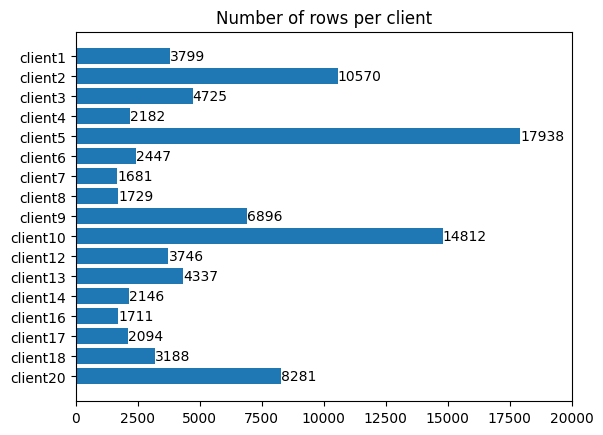

In [33]:
clients = list(DATA_PROVIDERS.keys())
values = list(DATA_PROVIDERS.values())

fig, ax = plt.subplots()

bar_container = ax.barh(clients, values)
ax.set(title='Number of rows per client', xlim=(0, 20000))
ax.invert_yaxis()
ax.bar_label(bar_container)

In [30]:
def plot_acc_time(clients_of_interest, client_df, global_df):
	fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(10, 12), sharex=True)
	# fig, ax1 = plt.subplots(figsize=(10, 5))

	for c in clients_of_interest:
		client_data = client_df[client_df['ClientID'] == c]
		x = client_data['Round']

		y1 = client_data['ClientAccuracy']
		ax1.plot(x,y1, marker='o', linestyle='-', label=f'{c}')
		y2 = client_data['ClientTrainingTime']
		ax2.plot(x,y2, marker='o', linestyle='-', label=f'{c}')

	ax1.plot(global_df['GlobalAccuracy'], marker='s', linestyle='-',  linewidth=2, color='black', label='GlobalAccuracy')
	ax3.plot(global_df['RoundDuration'], marker='s', linestyle='-',  color='magenta', label='RoundDuration')
	ax3.plot(global_df['TotalTrainingTime'], marker='s', linestyle='-',color='red', label='TotalTrainingTime')
	ax4.plot(global_df['AggregationTime'], marker='s', linestyle='-',  color='black', label='AggregationTime')
	
	n_rounds = len(client_data['Round'])
	ax1.set_xlabel('Round')
	ax1.set_ylabel('Accuracy')
	ax2.set_ylabel('Training Time [ms]')
	ax3.set_ylabel('Total times per round [ms]')
	ax4.set_ylabel('Aggregation Time per round [ms]')
	ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5))
	ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5))
	ax3.legend()
	plt.title(f'Accuracy/Training times for {n_rounds} rounds', y=1)
	plt.show()

In [19]:
def plot_energy(energy_df):
    # Remove linkerd-init containers (they have 0 energy)
    energy_df = energy_df[energy_df['container_name'] != 'linkerd-init']

    # Group by pod_name and container_name, sum the joules
    energy_by_container = energy_df.groupby(['pod_name', 'container_name'])['joules'].sum().reset_index()

    # Pivot to get containers as columns
    pivot_df = energy_by_container.pivot(index='pod_name', columns='container_name', values='joules')
    pivot_df = pivot_df.fillna(0)

    # Sort by total energy consumption
    pivot_df['total'] = pivot_df.sum(axis=1)
    pivot_df = pivot_df.sort_values('total', ascending=False)
    pivot_df = pivot_df.drop('total', axis=1)

    # Create the stacked bar chart
    fig, ax = plt.subplots(figsize=(10, 6))

    # Define colors for different container types
    container_colors = {
        'linkerd-proxy': '#FF6B6B',
        'sidecar': '#4ECDC4',
        'hfl-train': '#45B7D1',
        'hfl-train-model': '#96CEB4',
        'policy-enforcer': '#FFEAA7',
        'orchestrator': '#DFE6E9',
        'api-gateway': '#A29BFE',
        'server': '#FD79A8'
    }

    # Assign colors to client containers
    client_containers = [col for col in pivot_df.columns if col.startswith('client')]
    for container in client_containers:
        container_colors[container] = '#74B9FF'

    # Create the stacked bar chart
    bottom = np.zeros(len(pivot_df))
    bar_width = 0.6

    for container in pivot_df.columns:
        color = container_colors.get(container, '#95A5A6')
        ax.bar(pivot_df.index, pivot_df[container], bar_width, 
            label=container, bottom=bottom, color=color)
        bottom += pivot_df[container].values

    # Customize the chart
    ax.set_xlabel('Pod Name', fontsize=12, fontweight='bold')
    ax.set_ylabel('Energy Consumption (Joules)', fontsize=12, fontweight='bold')
    ax.set_title('Energy Consumption by Pod and Container', fontsize=14, fontweight='bold')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, title="Container")
    ax.set_xticks(range(len(pivot_df)))
    ax.set_xticklabels(pivot_df.index, rotation=45, ha='right', fontsize=8)
    plt.tight_layout()
    plt.grid(axis='y', alpha=0.3)

    # Add total values on top of bars
    for i, (_, row) in enumerate(pivot_df.iterrows()):
        total = row.sum()
        ax.text(i, total, f'{total:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.show()

    # # Print summary statistics
    # print("\n=== Energy Consumption Summary ===")
    # print(f"\nTotal energy by namespace:")
    # totals = pivot_df.sum(axis=1).sort_values(ascending=False)
    # for namespace, total in totals.items():
    #     print(f"{namespace:20s}: {total:8.2f} J")

    # print(f"\nTotal energy by container type:")
    # container_totals = pivot_df.sum(axis=0).sort_values(ascending=False)
    # for container, total in container_totals.items():
    #     print(f"{container:20s}: {total:8.2f} J")

In [ ]:
client2 = 10570
client5 = 17938
client10 = 14812

tt_client2 = 509
tt_client5 = 791
tt_client10 = 645

In [ ]:
print(client2/client5)
print(tt_client2/tt_client5)
print(" ")
print(client2/client10)
print(tt_client2/tt_client10)
print(" ")
print(client10/client5)
print(tt_client10/tt_client5)
print(" ")

0.5892518675437618
0.6434892541087232
 
0.7136105860113422
0.7891472868217054
 
0.8257330806109934
0.8154235145385588
 


# 10 rounds, 3 biggest clients

In [38]:
L_3_client_10_df = pd.read_csv('/home/maurits/EnergyEfficient_Scattered-Directive/fabric/data/3/10/12-01-26-152535/client_stats.csv', index_col=0)
L_3_global_10_df = pd.read_csv('/home/maurits/EnergyEfficient_Scattered-Directive/fabric/data/3/10/12-01-26-152535/global_stats.csv', index_col=0)
L_3_energy_10_df = pd.read_csv('/home/maurits/EnergyEfficient_Scattered-Directive/fabric/data/3/10/12-01-26-152535/energy_consumption.csv', index_col=0)

In [ ]:
L_3_global_10_df['RoundDuration'] = L_3_global_10_df['RoundDuration']/1000000

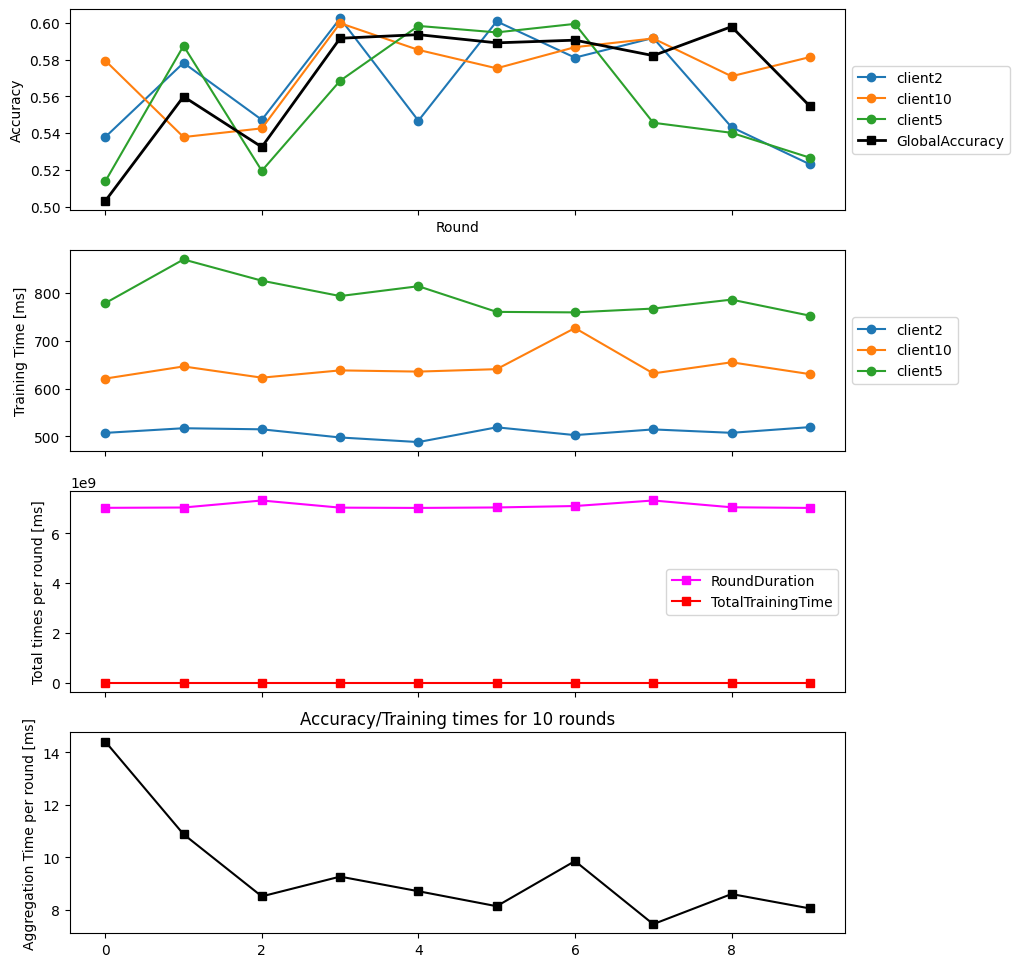

In [39]:
clients_of_interest = ['client2', 'client10', 'client5'] 
plot_acc_time(clients_of_interest, L_3_client_10_df,L_3_global_10_df)

/tmp/ipykernel_4703/443723777.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  plot_energy(energy_df[energy_df['pod_name'].str.contains(regex)])


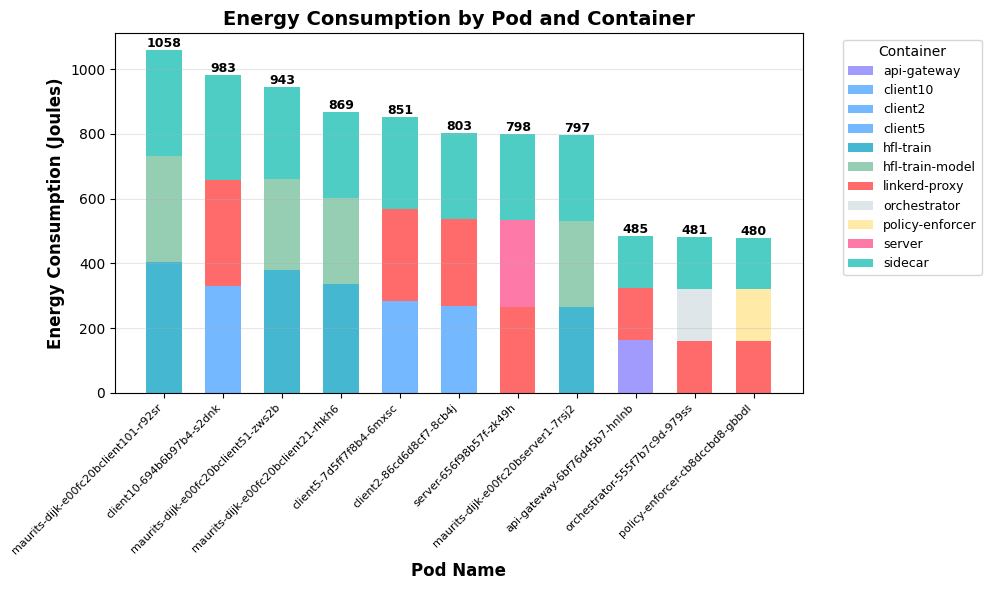

In [132]:
regex = 'client(2-|5-|10-)|server*|maurits-dijk*|api-gateway*|orchestrator*|policy-enforcer*'
plot_energy(energy_df[energy_df['pod_name'].str.contains(regex)])

# 20 rounds, 3 biggest clients

In [128]:
client_df = pd.read_csv('/home/maurits/EnergyEfficient_Scattered-Directive/fabric/data/3/20/12-01-26-153121/client_stats.csv', index_col=0)
global_df = pd.read_csv('/home/maurits/EnergyEfficient_Scattered-Directive/fabric/data/3/20/12-01-26-153121/global_stats.csv', index_col=0)
energy_df = pd.read_csv('/home/maurits/EnergyEfficient_Scattered-Directive/fabric/data/3/20/12-01-26-153121/energy_consumption.csv', index_col=0)

In [123]:
global_df['RoundDuration'] = global_df['RoundDuration']/1000000

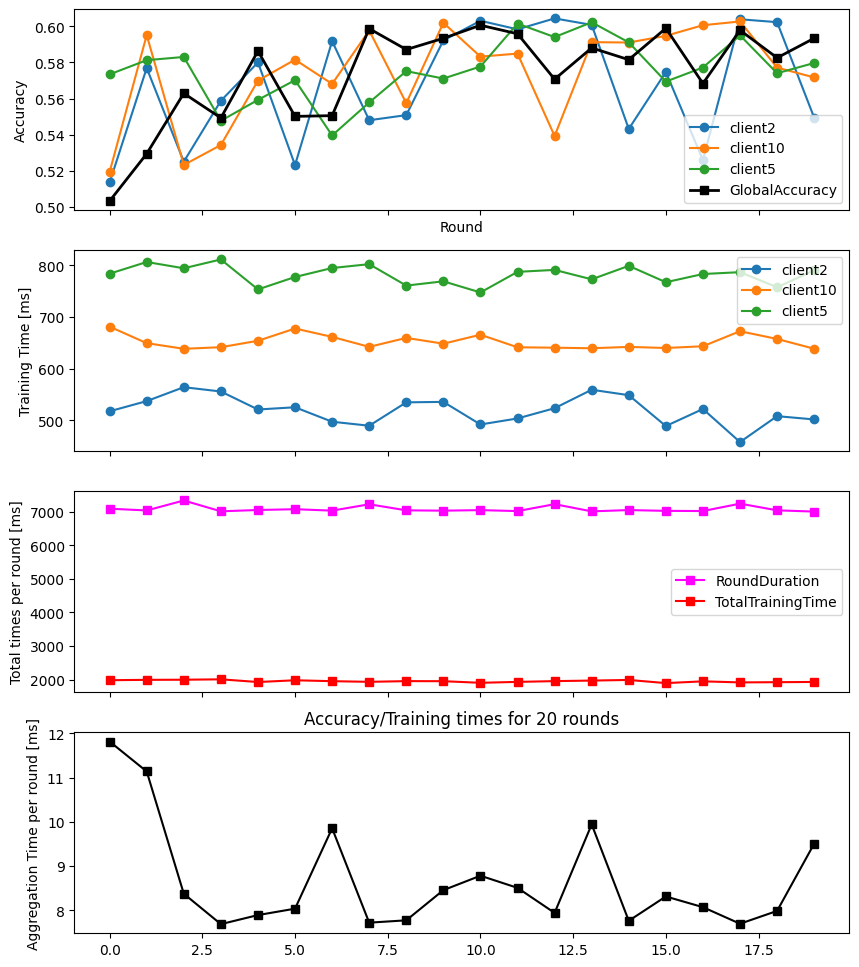

In [116]:
clients_of_interest = ['client2', 'client10', 'client5'] 
plot_acc_time(clients_of_interest, client_df, global_df)

/tmp/ipykernel_4703/443723777.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  plot_energy(energy_df[energy_df['pod_name'].str.contains(regex)])


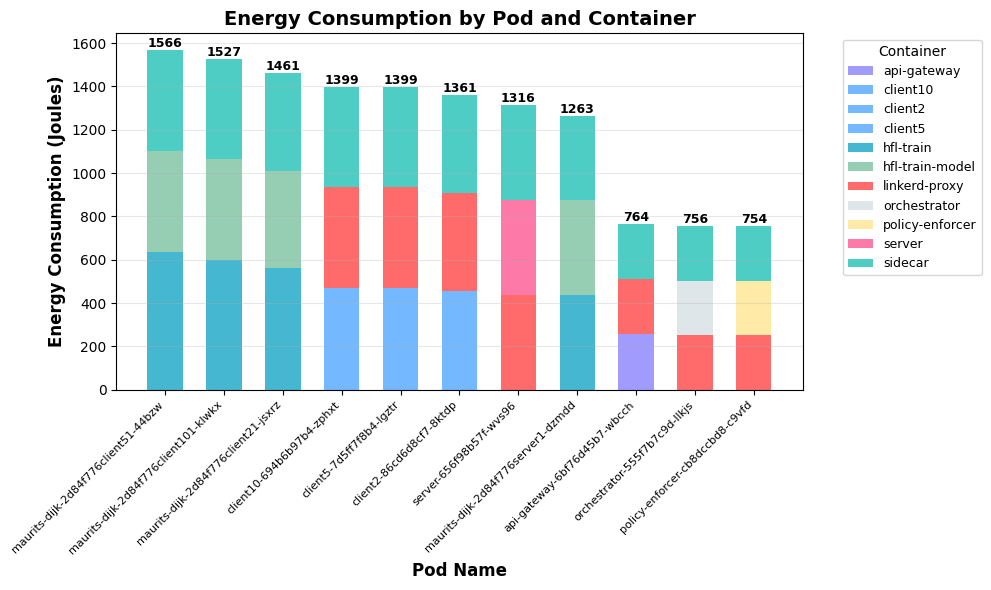

In [129]:
regex = 'client(2-|5-|10-)|server*|maurits-dijk*|api-gateway*|orchestrator*|policy-enforcer*'
plot_energy(energy_df[energy_df['pod_name'].str.contains(regex)])

# 30 rounds, 3 biggest clients

In [125]:
client_df = pd.read_csv('/home/maurits/EnergyEfficient_Scattered-Directive/fabric/data/3/30/12-01-26-153806/client_stats.csv', index_col=0)
global_df = pd.read_csv('/home/maurits/EnergyEfficient_Scattered-Directive/fabric/data/3/30/12-01-26-153806/global_stats.csv', index_col=0)
energy_df = pd.read_csv('/home/maurits/EnergyEfficient_Scattered-Directive/fabric/data/3/30/12-01-26-153806/energy_consumption.csv', index_col=0)

In [126]:
global_df['RoundDuration'] = global_df['RoundDuration']/1000000

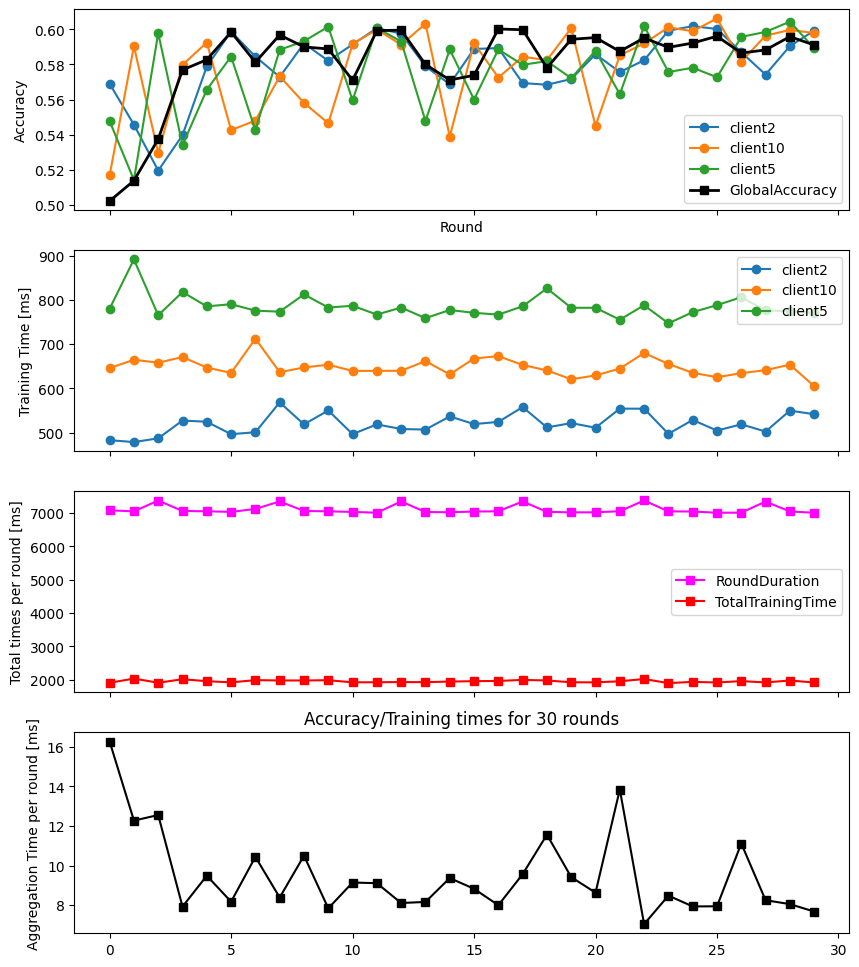

In [98]:
clients_of_interest = ['client2', 'client10', 'client5'] 
plot_acc_time(clients_of_interest, client_df, global_df)

/tmp/ipykernel_4703/443723777.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  plot_energy(energy_df[energy_df['pod_name'].str.contains(regex)])


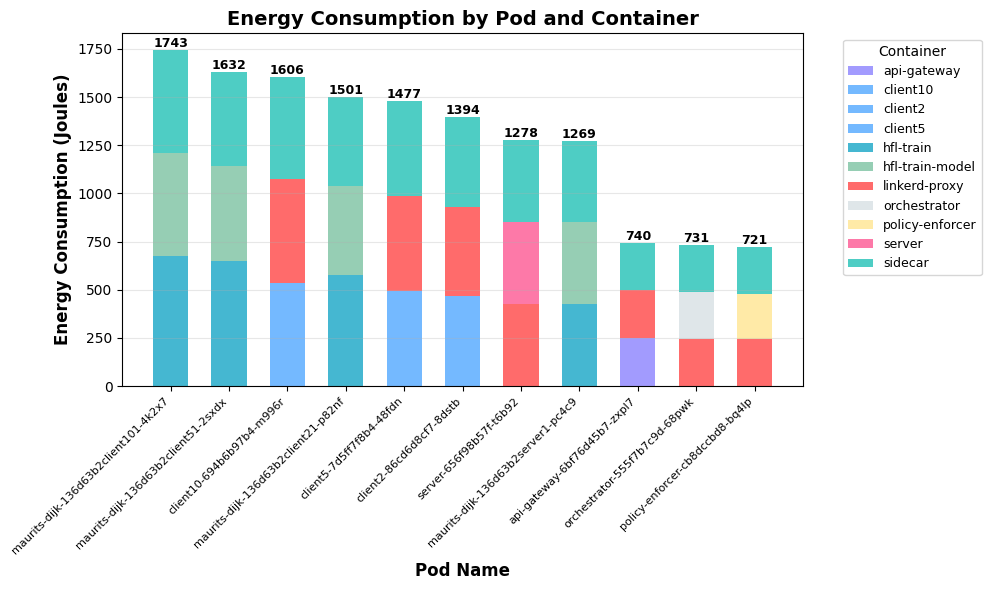

In [127]:
regex = 'client(2-|5-|10-)|server*|maurits-dijk*|api-gateway*|orchestrator*|policy-enforcer*'
plot_energy(energy_df[energy_df['pod_name'].str.contains(regex)])

# 10 rounds, 3 smallest clients

In [99]:
client_df = pd.read_csv('/home/maurits/EnergyEfficient_Scattered-Directive/fabric/data/3/10/13-01-26-165414/client_stats.csv')
global_df = pd.read_csv('/home/maurits/EnergyEfficient_Scattered-Directive/fabric/data/3/10/13-01-26-165414/global_stats.csv', index_col=0)
energy_df = pd.read_csv('/home/maurits/EnergyEfficient_Scattered-Directive/fabric/data/3/10/13-01-26-165414/energy_consumption.csv', index_col=0)

In [100]:
global_df['RoundDuration'] = global_df['RoundDuration']/1000000

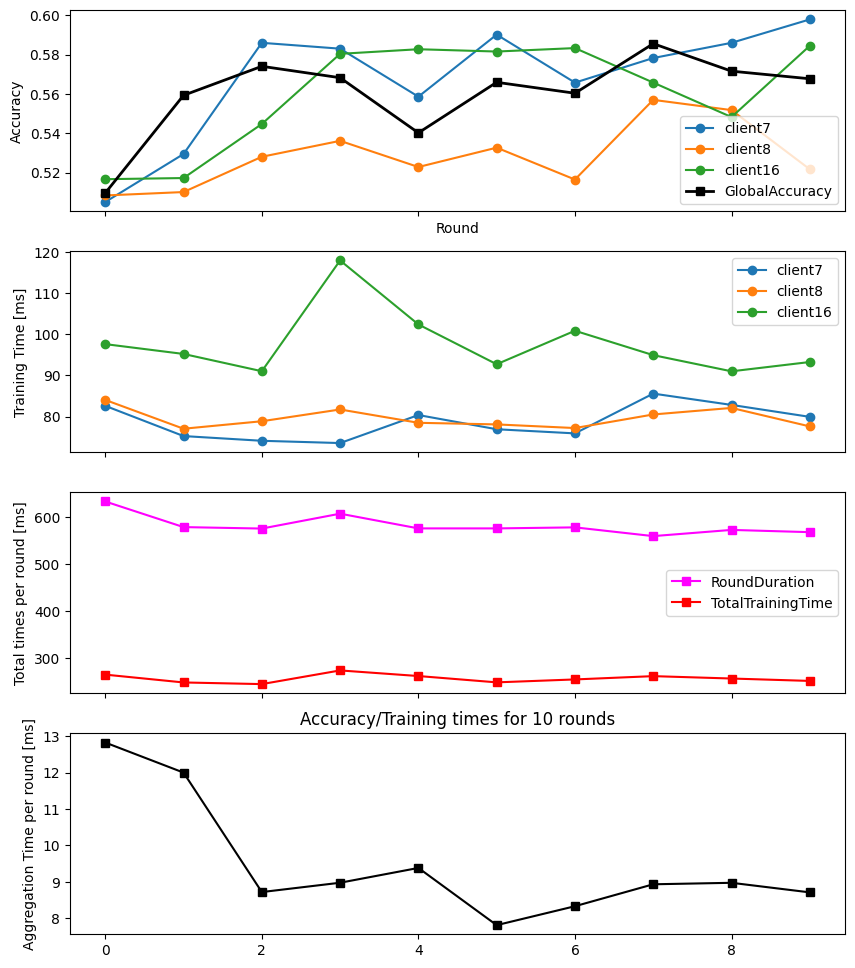

In [101]:
clients_of_interest = ['client7', 'client8', 'client16'] 
plot_acc_time(clients_of_interest, client_df, global_df)

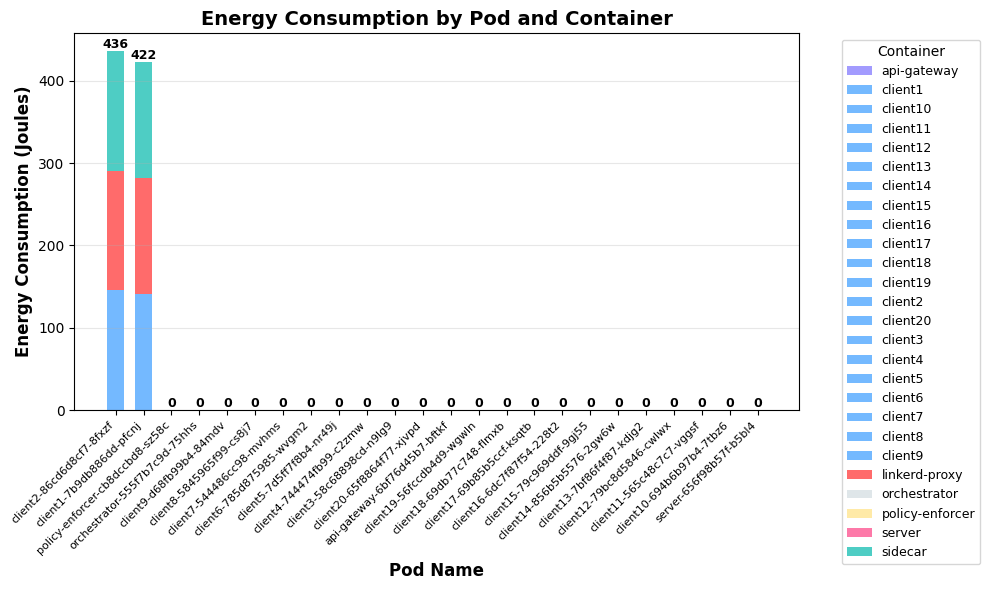

In [75]:
regex = 'client(7-|8-|16-)|server*|maurits-dijk*|api-gateway*|orchestrator*|policy-enforcer*'
plot_energy(energy_df)

# 20 rounds, 3 smallest clients

In [102]:
client_df = pd.read_csv('/home/maurits/EnergyEfficient_Scattered-Directive/fabric/data/3/20/13-01-26-165900/client_stats.csv')
global_df = pd.read_csv('/home/maurits/EnergyEfficient_Scattered-Directive/fabric/data/3/20/13-01-26-165900/global_stats.csv', index_col=0)
energy_df = pd.read_csv('/home/maurits/EnergyEfficient_Scattered-Directive/fabric/data/3/20/13-01-26-165900/energy_consumption.csv', index_col=0)

In [103]:
global_df['RoundDuration'] = global_df['RoundDuration']/1000000

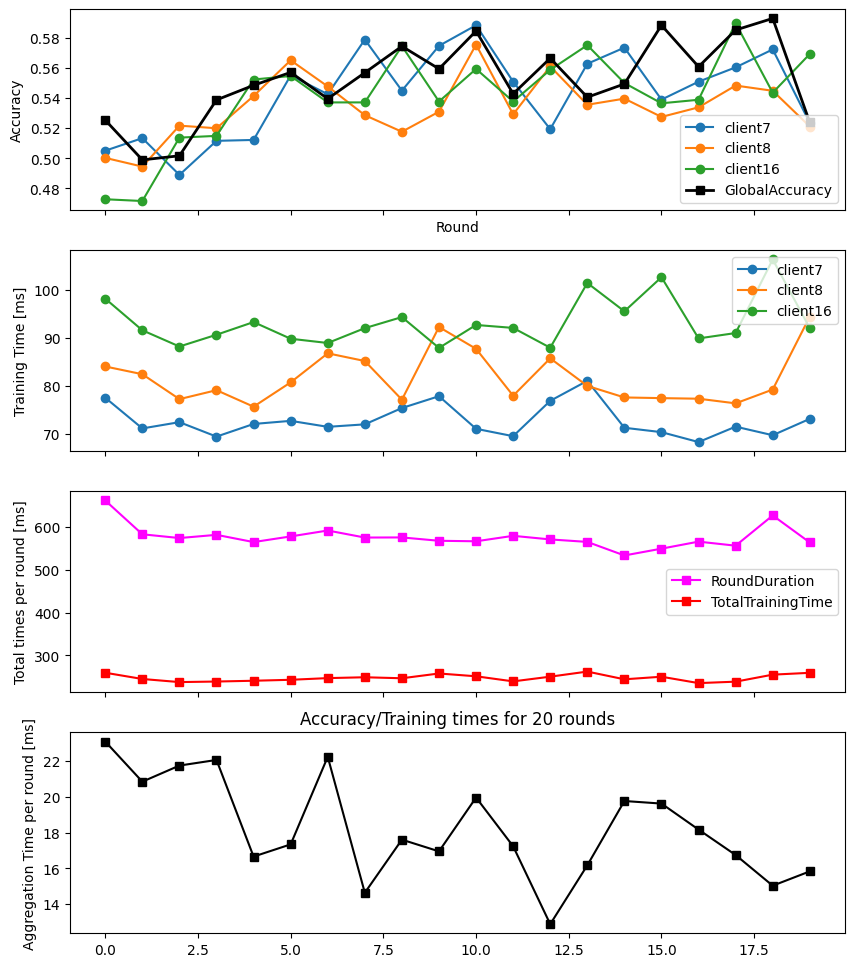

In [104]:
clients_of_interest = ['client7', 'client8', 'client16'] 
plot_acc_time(clients_of_interest, client_df, global_df)

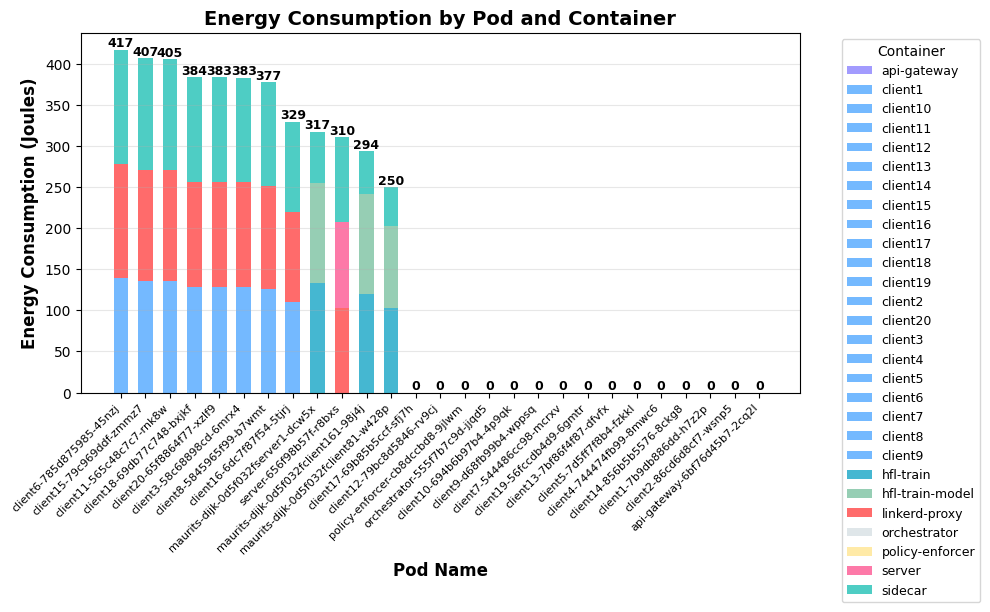

In [77]:
regex = 'client(7-|8-|16-)|server*|maurits-dijk*|api-gateway*|orchestrator*|policy-enforcer*'
plot_energy(energy_df)

# 30 rounds, 3 smalles clients

In [32]:
client_df = pd.read_csv('/home/maurits/EnergyEfficient_Scattered-Directive/fabric/data/3/30/13-01-26-170345/client_stats.csv')
global_df = pd.read_csv('/home/maurits/EnergyEfficient_Scattered-Directive/fabric/data/3/30/13-01-26-170345/global_stats.csv', index_col=0)
energy_df = pd.read_csv('/home/maurits/EnergyEfficient_Scattered-Directive/fabric/data/3/30/13-01-26-170345/energy_consumption.csv', index_col=0)

In [33]:
global_df['RoundDuration'] = global_df['RoundDuration']/1000000

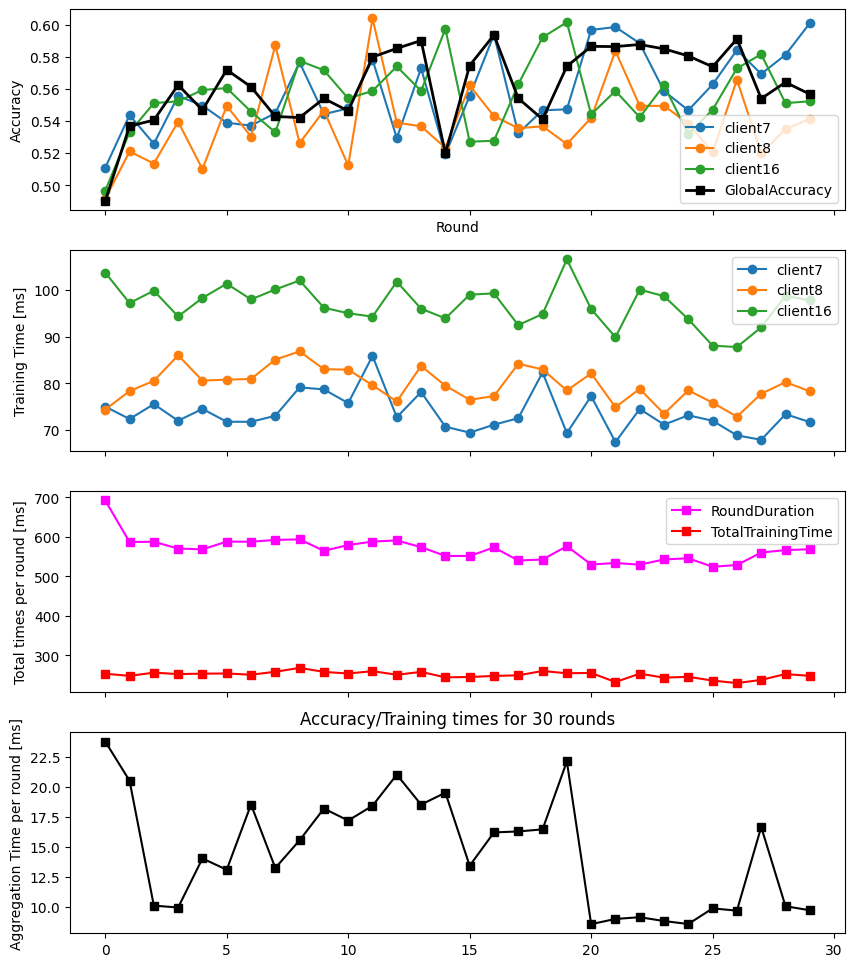

In [107]:
clients_of_interest = ['client7', 'client8', 'client16'] 
plot_acc_time(clients_of_interest, client_df, global_df)

/tmp/ipykernel_3568/3657851179.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  plot_energy(energy_df[energy_df['pod_name'].str.contains(regex)])


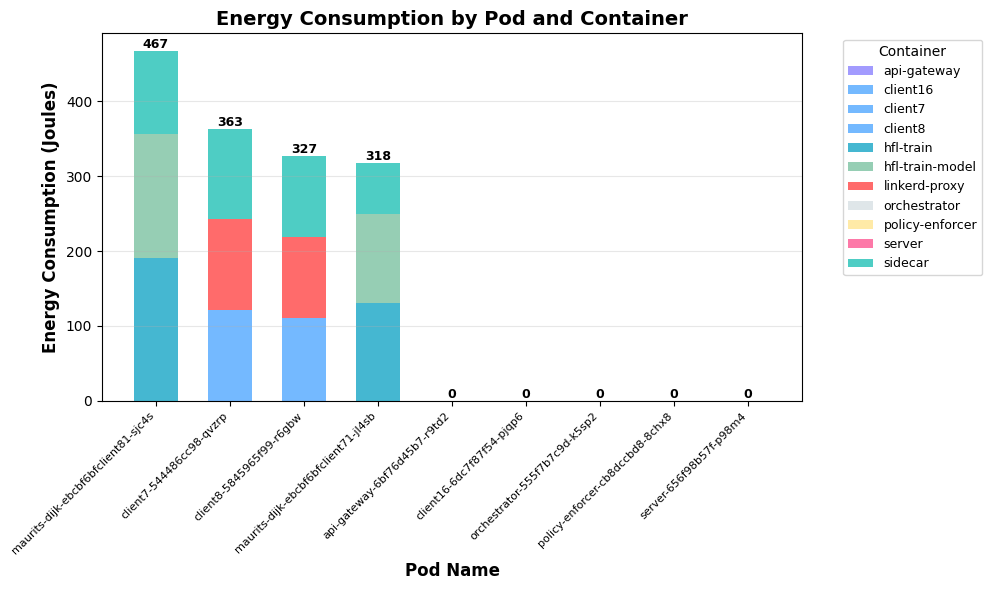

In [88]:
regex = 'client(7-|8-|16-)|server*|maurits-dijk*|api-gateway*|orchestrator*|policy-enforcer*'
plot_energy(energy_df[energy_df['pod_name'].str.contains(regex)])

# Location analysis
- Server = Amsterdam
- Client2 = Los Angeles
- Client5 = Amsterdam
- Client10 = Tokyo

Distance from client to server:
- Client2 = 8940 km
- Client5 = 0 km
- Client10 = 9300 km

- Client2 (Los Angeles): 46.27 J/round
- Client5 (Amsterdam):  49.11 J/round  
- Client10 (Tokyo):     53.40 J/round

In [10]:
OUTPUT_DIR = "analysis_output"
master = pd.read_csv(f"{OUTPUT_DIR}/experiment_summary.csv")
client_data = pd.read_csv(f"{OUTPUT_DIR}/all_client_stats.csv")
energy_data = pd.read_csv(f"{OUTPUT_DIR}/all_energy_stats.csv")

In [12]:
client_data

,Round,ClientID,ClientAccuracy,ClientTrainingTime,clients,rounds,timestamp,experiment
0,0,client7,0.525283,77.142213,5,20,22-01-26-105720,C5_R20_22-01-26-105720_small
1,0,client8,0.491035,77.939988,5,20,22-01-26-105720,C5_R20_22-01-26-105720_small
2,0,client17,0.515759,102.870526,5,20,22-01-26-105720,C5_R20_22-01-26-105720_small
3,0,client16,0.542957,99.380220,5,20,22-01-26-105720,C5_R20_22-01-26-105720_small
4,0,client14,0.515843,123.368351,5,20,22-01-26-105720,C5_R20_22-01-26-105720_small
...,...,...,...,...,...,...,...,...
10444,59,client16,0.608416,104.164809,10,60,22-01-26-124541,C10_R60_22-01-26-124541_small
10445,59,client14,0.592265,113.896514,10,60,22-01-26-124541,C10_R60_22-01-26-124541_small
10446,59,client4,0.603116,95.106569,10,60,22-01-26-124541,C10_R60_22-01-26-124541_small
10447,59,client1,0.605422,159.307228,10,60,22-01-26-124541,C10_R60_22-01-26-124541_small


In [61]:
energy_data[energy_data['namespace'] == 'client14' ].groupby('experiment').sum()

/tmp/ipykernel_28028/1899005051.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  energy_data[energy_data['namespace'] == 'client14' ].groupby('experiment').sum()


,joules,clients,rounds
experiment,,,
C10_R20_22-01-26-113955_small,3277.496,70,140
C10_R20_22-01-26-114637_small,3109.996,70,140
C10_R20_22-01-26-115322_small,2910.476,70,140
C10_R40_22-01-26-120006_small,2854.652,70,280
C10_R40_22-01-26-120846_small,755.871,70,280
C10_R40_22-01-26-121326_small,3122.564,70,280
C10_R60_22-01-26-122210_small,2999.052,70,420
C10_R60_22-01-26-123355_small,3166.512,70,420
C10_R60_22-01-26-124541_small,2909.348,70,420


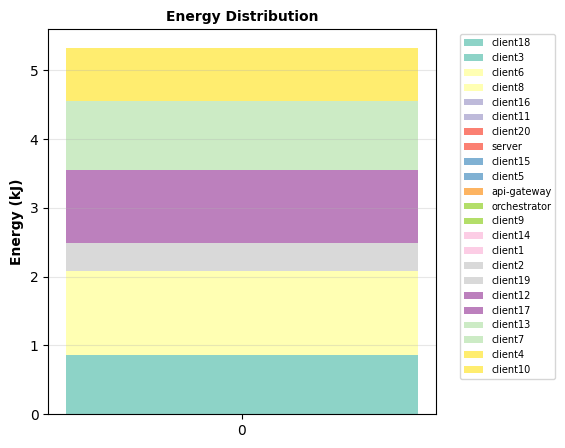

In [106]:
import matplotlib as mpl
from matplotlib import cm

fig = plt.figure(figsize=(5, 5))
# 1. Final Global Accuracy Comparison with Dataset Size
ax1 = plt.subplot()
# for ex in master['experiment']:
ex =master['experiment'][0]
ex_clients = client_data[client_data['experiment'] == ex]['ClientID'].unique()
exp_energy = energy_data[energy_data['experiment'] == ex]
# Prepare data for stacking
bottom = np.zeros(len(ex_clients))
colors_stack = cm.Set3(np.linspace(0, 1, len(ex_clients)))
values = exp_energy.groupby('namespace')['joules'].sum()

# for i,v in enumerate(values):
	# ax1.bar(ex_clients, values, bottom=bottom, label=c, color=colors_stack[i])
	# bottom += values

# Group by experiment and namespace
energy_by_exp_ns = exp_energy.groupby(['experiment', 'namespace'])['joules'].sum().reset_index()
    
# Create stacked bar chart
namespaces = []
for ns in exp_energy['namespace'].unique():
	if ns not in namespaces:
		namespaces.append(ns)

# Prepare data for stacking
bottom = np.zeros(1)
colors_stack = cm.Set3(np.linspace(0, 1, len(namespaces)))

for i, ns in enumerate(namespaces):
	values = []
	# for exp_id in exp_ids:
	exp_ns_energy = energy_by_exp_ns[(energy_by_exp_ns['experiment'] == ex) & 
										(energy_by_exp_ns['namespace'] == ns)]
	values.append(exp_ns_energy['joules'].sum() / 1000 if not exp_ns_energy.empty else 0)
	
	ax1.bar(range(1), values, bottom=bottom, label=ns, color=colors_stack[i])
	bottom += values

ax1.set_xticks(range(1))
ax1.set_ylabel('Energy (kJ)', fontweight='bold')
ax1.set_title('Energy Distribution', fontweight='bold', fontsize=10)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
ax1.grid(axis='y', alpha=0.3)